In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error , r2_score
import pylab
from scipy import stats

In [93]:
# Import the data
raw_df = pd.read_csv("ecommerce.csv")

In [94]:
# Let us look at the data and get a rough idea about it
print(f"Shape of the Data->\n{raw_df.shape}")
print(f"TOP ROWS OF THE DATASET ->\n{raw_df.head()}\n")

print(f"Info About the Data ->\n{raw_df.info()}")

Shape of the Data->
(500, 8)
TOP ROWS OF THE DATASET ->
                           Email  \
0      mstephenson@fernandez.com   
1              hduke@hotmail.com   
2               pallen@yahoo.com   
3        riverarebecca@gmail.com   
4  mstephens@davidson-herman.com   

                                             Address            Avatar  \
0       835 Frank Tunnel\nWrightmouth, MI 82180-9605            Violet   
1     4547 Archer Common\nDiazchester, CA 06566-8576         DarkGreen   
2  24645 Valerie Unions Suite 582\nCobbborough, D...            Bisque   
3   1414 David Throughway\nPort Jason, OH 22070-1220       SaddleBrown   
4  14023 Rodriguez Passage\nPort Jacobville, PR 3...  MediumAquaMarine   

   Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0            34.497268    12.655651        39.577668              4.082621   
1            31.926272    11.109461        37.268959              2.664034   
2            33.000915    11.330278        37.11

`We see that there are No Null values in our data which is quite good `

`Also the data is cleaned so we do not need to clean the data `

In [95]:
# Let us look at the numeric columns and have a closer look at the data
print(raw_df.describe())

       Avg. Session Length  Time on App  Time on Website  \
count           500.000000   500.000000       500.000000   
mean             33.053194    12.052488        37.060445   
std               0.992563     0.994216         1.010489   
min              29.532429     8.508152        33.913847   
25%              32.341822    11.388153        36.349257   
50%              33.082008    11.983231        37.069367   
75%              33.711985    12.753850        37.716432   
max              36.139662    15.126994        40.005182   

       Length of Membership  Yearly Amount Spent  
count            500.000000           500.000000  
mean               3.533462           499.314038  
std                0.999278            79.314782  
min                0.269901           256.670582  
25%                2.930450           445.038277  
50%                3.533975           498.887875  
75%                4.126502           549.313828  
max                6.922689           765.518462  


`We have a pretty normal looking data, I cannot see any outliers in any columns`

In [96]:
# Let us drop all the unnecessary columns for our analysis
df = raw_df[['Avg. Session Length','Time on App','Time on Website','Length of Membership','Yearly Amount Spent']]

#### Exploratory Data Analysis

#### For Fitting Linear Regression, we must check a few assumptions of the data
`(i) The Features are lienarly distributed with the target individually`                                                   
`(ii) Normality of the Residuals must be followed`                                                                         
`(iii) The data must follow Homoskedasticity i.e (the variance of errors must be constant)`

`Univariate Analysis`

#### Normality of Features

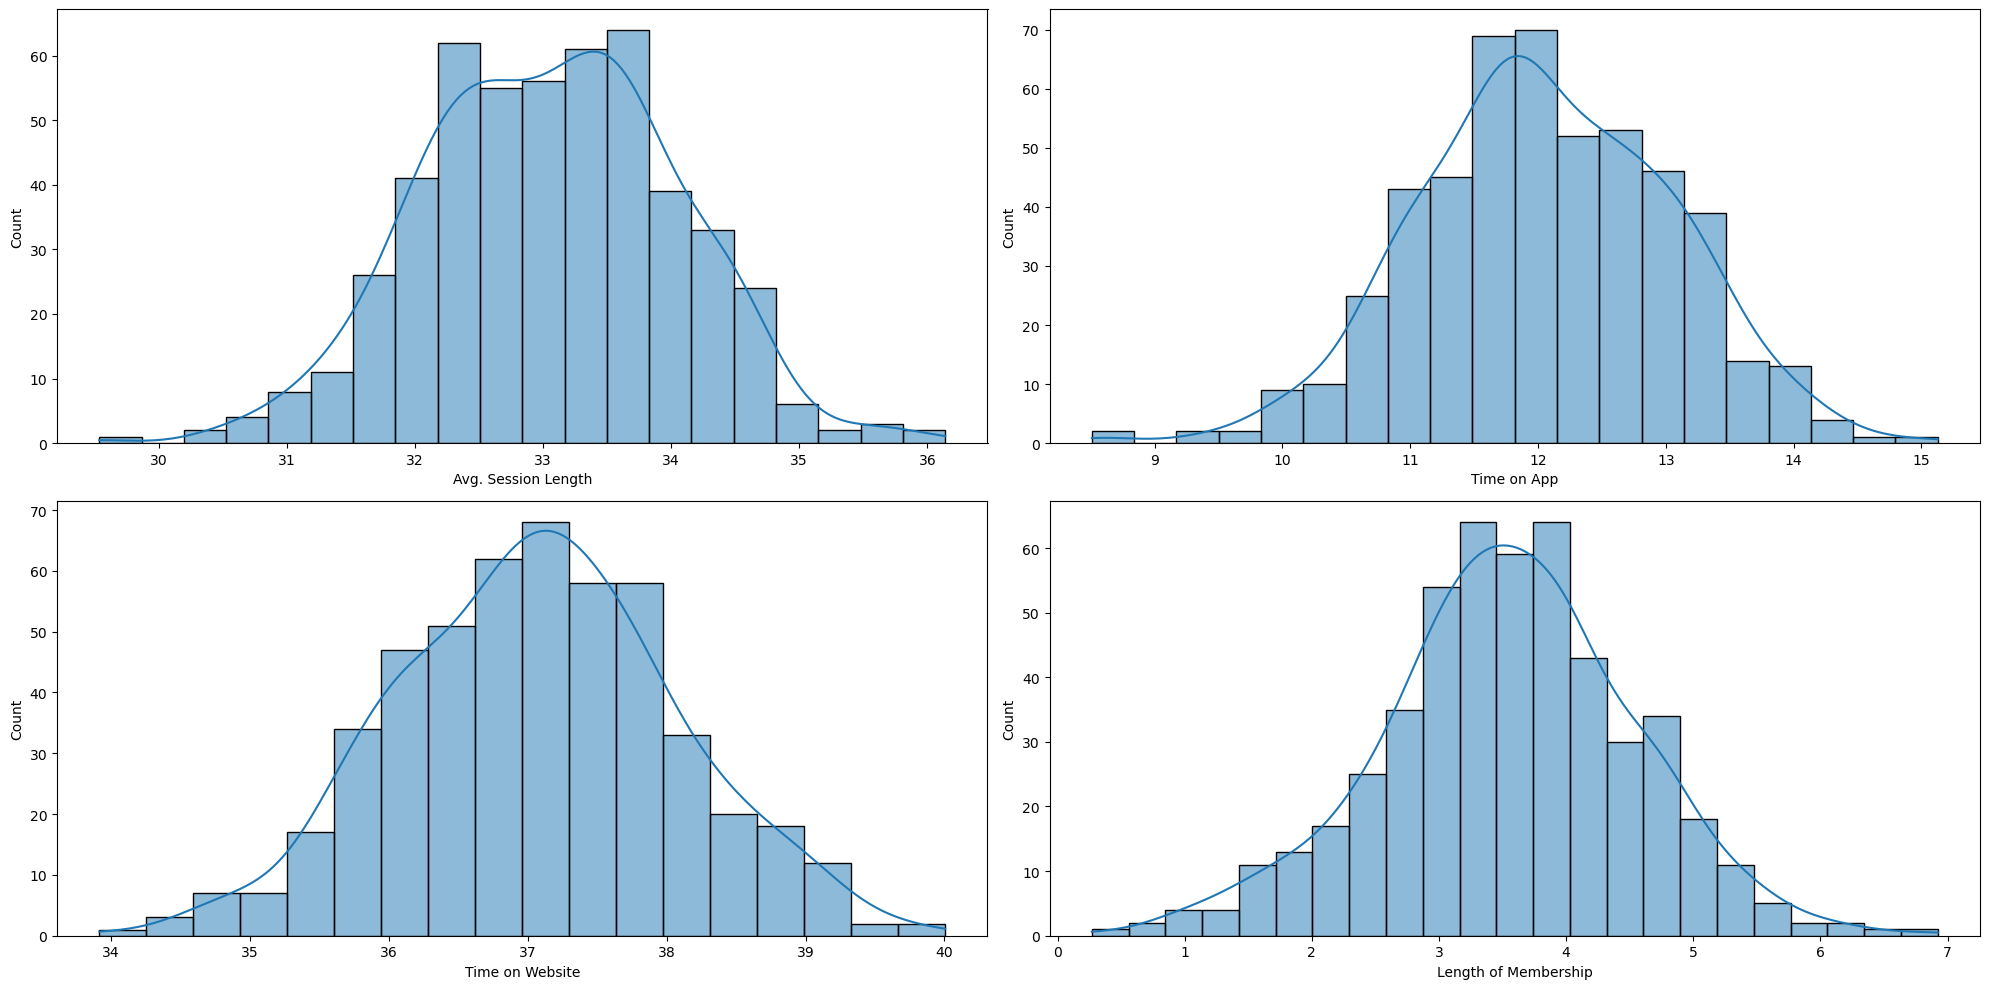

In [97]:
# Average Session Length 
fig , axes = plt.subplots(2,2 , figsize=(20,10))
sns.histplot(data = df ,x = "Avg. Session Length" , kde=True , ax = axes[0,0])
sns.histplot(data = df ,x = "Time on App" , kde=True , ax = axes[0,1])
sns.histplot(data = df ,x = "Time on Website" , kde=True , ax = axes[1,0])
sns.histplot(data = df ,x = "Length of Membership" , kde=True , ax = axes[1,1])
plt.tight_layout()
plt.show()


In [98]:
# Looking at skewness and Kurtosis of each Feature -> Shows if there are any asymmetry and outliers
for feature in df:
    print(f"Skewness -> {df[feature].skew()}")
    print(f"Kurtosis -> {df[feature].kurtosis()}")
    print()

Skewness -> -0.03217480705175727
Kurtosis -> 0.011861627888115844

Skewness -> -0.08912109751093247
Kurtosis -> 0.12508121025175845

Skewness -> 0.012141880271484171
Kurtosis -> -0.09828689960707004

Skewness -> -0.10660805308864045
Kurtosis -> 0.349009786300309

Skewness -> 0.03479018411523428
Kurtosis -> 0.46397553251064316



`-- your distribution has tail behavior close to normal`                                                            
`-- no unusually heavy tails`                                                                                             
`-- no strong outlier tendency`                                                                                  

`This looks normally distributed`

`Almost Zero Skewness and Kurtosis signify the near symmetric Distribution and Also No fatter tails, So data is normal`

In [99]:
# To confirm it let us perfrom shapiro wilk test
for feature in df.columns:
    t_stats , p_value = stats.shapiro(df[feature])
    print(f"{feature} -> {p_value}\n")
    if p_value > 0.05 :
        print(f"Column {feature} is Normally Distributed!")
    else:
        print(f"Column {feature} is Not Normally Distributed!")

Avg. Session Length -> 0.7162786350158535

Column Avg. Session Length is Normally Distributed!
Time on App -> 0.5547034656773069

Column Time on App is Normally Distributed!
Time on Website -> 0.9364197858055993

Column Time on Website is Normally Distributed!
Length of Membership -> 0.2745382979349808

Column Length of Membership is Normally Distributed!
Yearly Amount Spent -> 0.26424641288276424

Column Yearly Amount Spent is Normally Distributed!


`So we confirmed that all the Features are normally distributed. We do not necessarily need this assumption but We found it do its fine. Though we must check Normality of Residuals`

**All features passed Shapiro-Wilk test, so they're approximately normal**                                             
This is good for linear regression (assumes normality of residuals, not necessarily features)                             
Skewness values are all very close to 0 (range: -0.11 to 0.04), meaning nearly perfect symmetry                            
This means you DON'T need to transform your features (no log/square root needed)                                      

`Conclusion:`
**"All features are approximately normally distributed with minimal skewness. No transformation required."**

#### Bi-variate Analysis

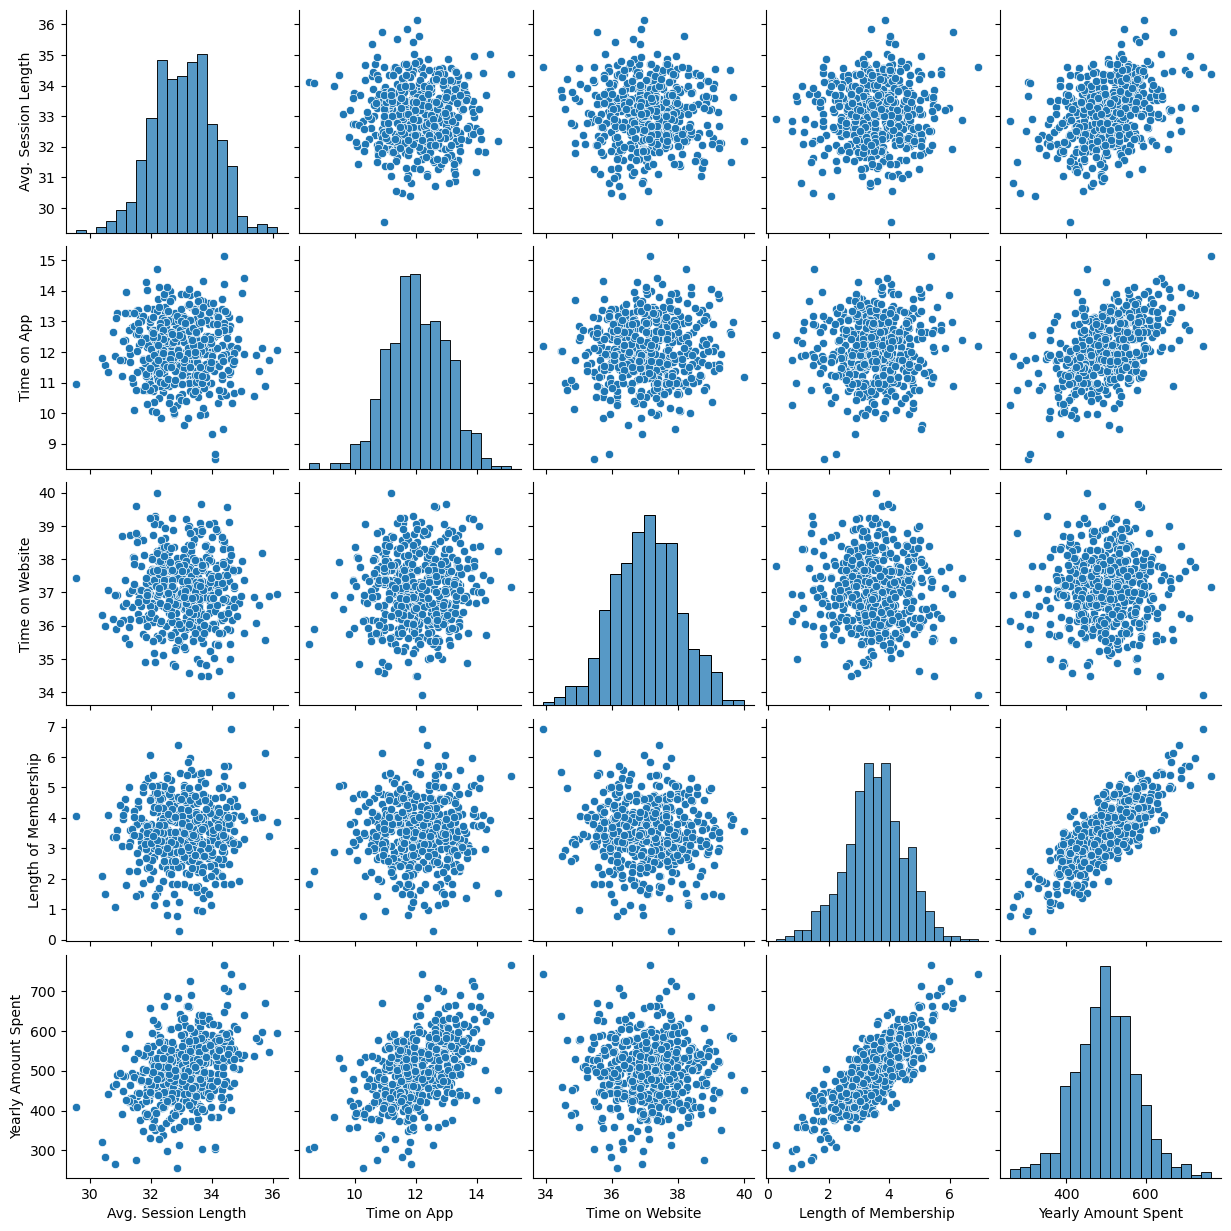

In [100]:
# Plotting Scatter plots about feature and target
sns.pairplot(data=df)

**Since we only care about the distribution of Feature with respect to our Target Column, we will look at the last row**

`No correlation b/w Avg Session Length and Yearly Spent`                                                                 

`Some Positive Correlation b/w Time on App and Yearly Spent`                                                              

`Similarly No Correlation b/w Time on Website and Yearly Spent`                                                        

`Heavily Positive correlation b/w Length of Membership and Yearly Spent`

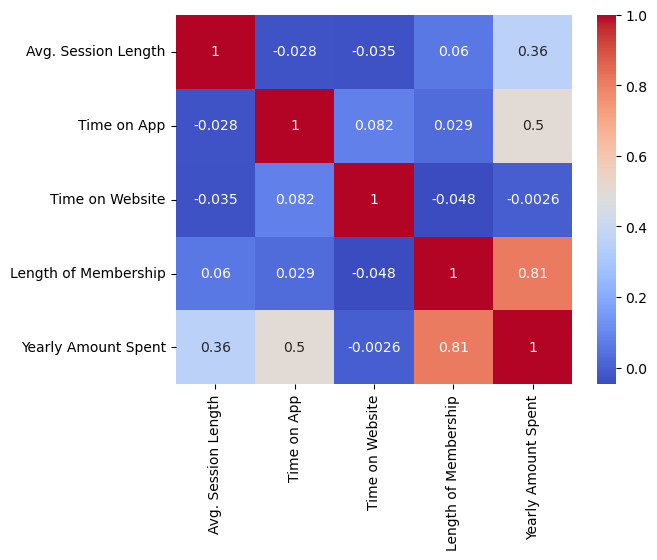

In [101]:
# Let us plot the correlation plot 
corr = df.corr()
sns.heatmap(corr , annot=True , cmap = 'coolwarm')
plt.show()

`Conclusion`                                                                           
**Yearly Spent and Length of Membership has 0.81 Correlation -> Heavily Positive Correlated**                              
**Yearly Spent and Time On App has 0.5 Correlation -> Positive Correlated**                                        
**Yearly Spent and Avg Session also has 0.36 Correlation -> Positive Correlated but slightly**    

#### Check for Multicollinearity b/w the features

`From Above heatmap we clearly see that the features are Not Correlated b/w each other`

**Thus Now We can Fit our Linear Regression Model and Predict and Evaluate the Outcomes**

In [102]:
X = df.drop(columns = ['Yearly Amount Spent'])

In [103]:
y = df['Yearly Amount Spent']

In [104]:
print(X.shape)
print(y.shape)

(500, 4)
(500,)


In [105]:
# Let us Split the training and Testing Data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2 , random_state = 42)

In [106]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 4)
(100, 4)
(400,)
(100,)


In [107]:
lr = LinearRegression()

model = lr.fit(X_train,y_train) # Fitting the model

y_pred = model.predict(X_test) # Predicting the values from Test Input data



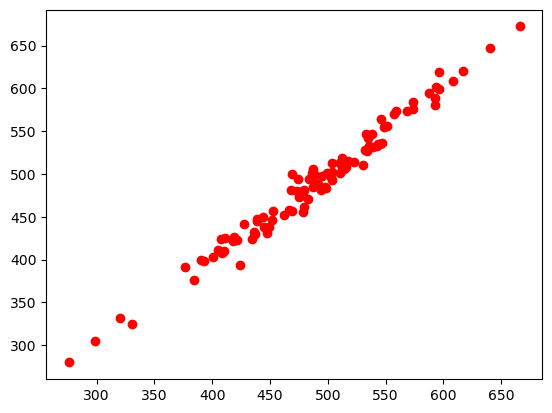

In [108]:
# Let us plot the data 
plt.scatter(y_test,y_pred, color='red')
plt.show()

`CLearly the Data b/w testing Output Data and Predicted Output looks Almost linear and a straight line`                   
`Shows that the model has fitted really good`

In [109]:
# Let us calculate the values of Intercept and Coefficients
print(f"Intercpet -> {lr.intercept_}")
print(f"Coefficients -> {lr.coef_}")

Intercpet -> -1044.2574146365569
Coefficients -> [25.5962591  38.78534598  0.31038593 61.89682859]


**Let us check the Errors in our Predictions**

In [110]:
MAE = mean_absolute_error(y_test,y_pred)
RMSE = root_mean_squared_error(y_test,y_pred)
r2_train = r2_score(y_train , lr.predict(X_train))
r2_test = r2_score(y_test,y_pred)
print(f"Mean Absolute Error -> {MAE}")
print(f"Root Mean Squared Error -> {RMSE}")
print(f"Training R2 Score -> {r2_train}")
print(f"Testing R2 Score -> {r2_test}")

Mean Absolute Error -> 8.558441885315233
Root Mean Squared Error -> 10.481590584636473
Training R2 Score -> 0.9854240629700333
Testing R2 Score -> 0.9778130629184126


`Clearly We evaluated the R2 Score of both Training Data and Testing Data to check if the model overfitted or underfitted`

In [111]:
r2_absolute_error = np.abs(r2_train - r2_test)
print(f"Absolute Difference b/w R2 Score of Training Data and Testing Data ->\n{r2_absolute_error}")

Absolute Difference b/w R2 Score of Training Data and Testing Data ->
0.007611000051620631


`Clearly the absolute diff < 0.05 Thus we can say that the Linear Regression model is Perfectly Fitted`

**Evaluating Residuals**

In [112]:
# Let us Calculate the Residuals and Study it
residuals = y_test - y_pred

In [113]:
print(residuals)

361    -1.829165
73     -7.756069
374    -8.017377
155     2.064515
104     0.402956
         ...    
347     4.827772
86      2.197933
75     22.788656
438    -5.685951
15     10.072051
Name: Yearly Amount Spent, Length: 100, dtype: float64


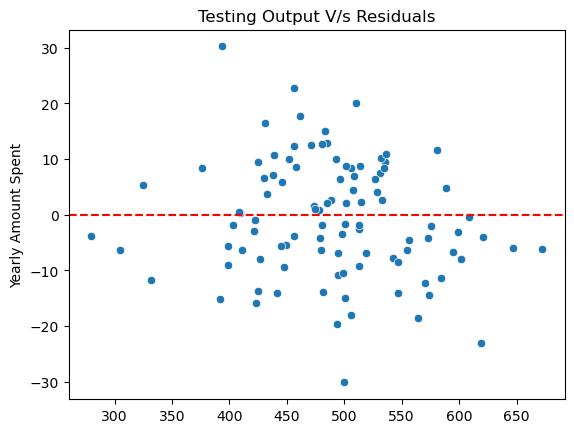

In [114]:
# Plotting the residuals
sns.scatterplot(x = y_pred , y = residuals)
plt.axhline(0 , linestyle='--' ,color='red')
plt.title("Testing Output V/s Residuals")
plt.show()

<Axes: xlabel='Yearly Amount Spent', ylabel='Count'>

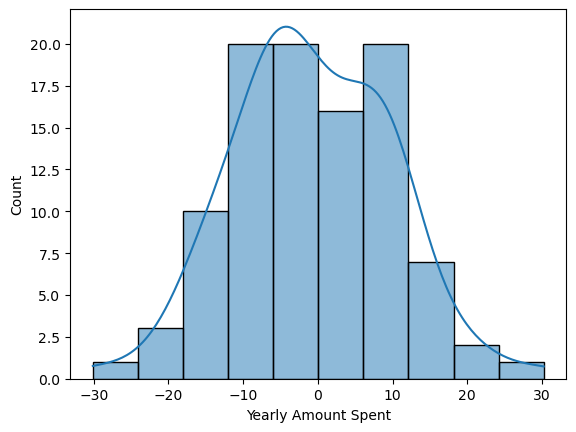

In [115]:
# Let us check the Normality of Residuals 
sns.histplot(residuals,bins=10,kde=True)

In [116]:
# using Shapiro test
stat , pvalue = stats.shapiro(residuals)
print(f"P value -> {pvalue}")

P value -> 0.9342124233733596


`Clearly p > 0.05 implies that Residuals are Normally Distributed`

In [117]:
# Using Omnibus Test
stat , pvalue = stats.normaltest(residuals)
print(f"P value -> {pvalue}")

P value -> 0.8286156572264038


`Again p>0.05 Thus Null Hypothesis cannot be rejected -> Residuals are Normally Distributed`

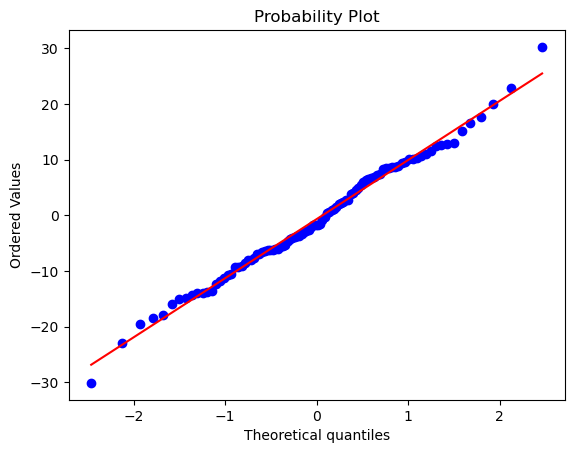

In [118]:
stats.probplot(residuals , dist='norm' , plot=pylab)
plt.show()

`This also confirms the Residuals are Normally Distributed`

**I hope you found this Mini Project useful and you actually gained something from this**

**Cross Validation**

In [119]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print(f"Mean R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Mean R² = 0.9837 ± 0.0019


In [120]:
import statsmodels.api as sm

`Here is the detailed Overview of the Summary of The Model we fit in`

In [121]:
# Checking the Summary of the Model Fitting
X_train_w_const = sm.add_constant(X_train)

In [122]:
#fit an OLS model using all three predictor variables

OLS_model = sm.OLS(y_train , X_train_w_const).fit()

In [123]:
print(OLS_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.985
Model:                             OLS   Adj. R-squared:                  0.985
Method:                  Least Squares   F-statistic:                     6676.
Date:                 Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                         12:46:05   Log-Likelihood:                -1480.1
No. Observations:                  400   AIC:                             2970.
Df Residuals:                      395   BIC:                             2990.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -

**What do we Infer from this**

#### (i.) P value of F- statistic is 0 <0.05 this means that Our Output is Highly dependent on the Input Columns Or at least one of the Input columns is Significant for our output...
 
#### (ii.) Feature "Time On Website does not play a crucial role in Total Yearly Spent"       
#### i.e there is no relation of customer spending more if he/she stays long on Website

#### (iii.) From Condition Number ~ 259 suggests that there is strong multicollinearity between the features , this tells us that WE cannot make Inferences by looking at the individual features

`Let us fit The model again but this time without "Time On Website" Feature `

In [126]:
X_train_without_web= X_train[['Avg. Session Length','Time on App','Length of Membership']]

In [127]:
X_train_without_web_w_const = sm.add_constant(X_train_without_web)

In [ ]:
model_OLS_without_web = sm.OLS(y_train , X_train_without_web_w_const).fit()

In [129]:
print(model_OLS_without_web.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.985
Model:                             OLS   Adj. R-squared:                  0.985
Method:                  Least Squares   F-statistic:                     8915.
Date:                 Sun, 10 May 2026   Prob (F-statistic):               0.00
Time:                         12:59:58   Log-Likelihood:                -1480.3
No. Observations:                  400   AIC:                             2969.
Df Residuals:                      396   BIC:                             2985.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -

`Summary Of The Comparison of Two Models We fitted`

`R-squared and Adj. R-squared — both stayed at 0.985`
R² measures what fraction of the variance in "Yearly Amount Spent" is explained by the model. Both models give 0.985 — meaning 98.5% of variance is explained. This makes complete sense because the feature you dropped ("Time on Website") was contributing essentially nothing. Its coefficient was only 0.31 with a p-value of 0.524, which means it had no real predictive power. Removing a useless feature doesn't hurt fit at all.
Adjusted R² penalizes you for adding extra features. The fact that it also stayed at 0.985 (didn't increase even slightly) confirms that "Time on Website" was genuinely a dead weight feature — it wasn't even doing accidental damage.

`F-statistic jumped from 6,676 → 8,915`
F-statistic tests whether the model as a whole is statistically significant. A higher F-statistic is better — it means more of the variation is explained by your features relative to the residual noise. When you remove a feature that adds noise (even a small amount), the ratio improves significantly. Going from 6,676 to 8,915 is a ~33% jump, even though the fit didn't change at all. This is because the denominator (residual variance estimate) is now using one fewer parameter and one more degree of freedom, making the test sharper.

`AIC and BIC both dropped (good)`
AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) are model selection criteria — lower is better. Both penalize model complexity (number of parameters) to discourage overfitting.

AIC: 2970 → 2969 (dropped by 1)
BIC: 2990 → 2985 (dropped by 5)

BIC penalizes extra parameters more harshly than AIC (the penalty is log(n) * k vs 2k in AIC, where n=400 and k=number of parameters). So BIC drops more aggressively when you remove a useless feature. The message here: Model 2 is officially a more parsimonious and better model by both criteria, even if only slightly.

`Condition Number halved: 2590 → 1280`
This is actually the most practically important improvement. The condition number measures multicollinearity — how correlated your features are with each other. A very high condition number means the X'X matrix is nearly singular, making coefficient estimates unstable and unreliable.
The rule of thumb: condition number > 1000 is concerning, > 3000 is severe. Both models are still above 1000 (hence both show that warning note), but dropping from 2590 to 1280 is a significant improvement. It means "Time on Website" was sharing information with the other features in a way that made the system of equations harder to solve precisely. Removing it made the remaining features more independent of each other.

`Standard error of the intercept dropped sharply: 24.89 → 17.72`
The intercept (const) went from ±24.89 to ±17.72. That's a 29% reduction in uncertainty. The other three coefficients barely moved (std err is essentially the same). This means "Time on Website" was most strongly correlated with the intercept estimation — it was essentially stealing explanatory power from the baseline.

`Residual diagnostics didn't change at all`
Durbin-Watson (~2.0 in both) → no autocorrelation in residuals. Prob(Omnibus) and Prob(JB) both >> 0.05 → residuals are normally distributed in both models. Skew near 0 and Kurtosis near 3 → clean residuals. Your model's assumptions are satisfied in both cases.


**Bottom line**
`Model 2 (without "Time on Website") is strictly better. Same explanatory power (R²), higher F-statistic, lower AIC/BIC, lower multicollinearity, and more stable intercept estimate — all with fewer parameters. This is exactly the textbook outcome you want from feature selection: remove insignificant features and the model becomes cleaner without losing anything.`